In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 기본


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [ ]:
# csv 파일 불러오기
file_path = '/content/drive/MyDrive/서울시 빅데이터 공모전/data/processed/df_final_all_preprocessed.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig', low_memory=False)
df.head()

,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


In [ ]:
# 데이터 기본 확인
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum())
df.head()

(73964, 15)
['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량']
사용월               0
호선명               0
time_group        0
혼잡                0
역명_clean          0
구조평균              0
구조최소              0
구조최대              0
사고수               0
유입                0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
환승량               0
dtype: int64


,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


# 사고수 -> 사고발생 여부로 변환

In [ ]:
# 사고발생 여부 타깃 변수 생성
# 사고수 > 0 이면 실제 사고가 발생한 경우이므로 1
# 사고수 = 0 이면 사고가 발생하지 않은 경우이므로 0
# 즉, 사고 "건수" 예측이 아니라 사고 "발생 여부"를 예측하는 이진분류 문제로 변환

df['사고발생'] = (df['사고수'] > 0).astype(int)

# 사고발생/미발생 데이터 개수 확인
print(df['사고발생'].value_counts())

# 사고발생/미발생 비율 확인
# 클래스 불균형 정도를 확인하기 위한 단계
print(df['사고발생'].value_counts(normalize=True))

사고발생
0    73152
1      812
Name: count, dtype: int64
사고발생
0    0.989022
1    0.010978
Name: proportion, dtype: float64


In [ ]:
# 컬럼명 확인
print(df.columns.tolist())

['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량', '사고발생']


In [ ]:
# 숫자형 변수 전처리
# 모델 학습에 사용할 주요 변수들을 숫자형으로 변환하는 단계
# CSV를 불러오면 숫자가 문자열로 들어오거나, 쉼표(,)가 포함되어 있을 수 있기 때문에 정리 필요

num_cols = [
    '혼잡', '유입', '구조평균', '구조최소', '구조최대',
    '환승량',
    'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum'
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                         # 문자열로 변환
        .str.replace(',', '', regex=False)   # 숫자 안의 쉼표 제거
        .str.strip()                         # 앞뒤 공백 제거
    )

    # 숫자로 변환
    # 변환이 안 되는 값은 NaN으로 처리
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 변환 과정에서 생긴 결측치 NaN을 각 컬럼의 중앙값으로 대체
# 평균보다 중앙값이 이상치 영향을 덜 받아서 안전함
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 결측치가 남아 있는지 확인
print(df[num_cols].isna().sum())

혼잡                0
유입                0
구조평균              0
구조최소              0
구조최대              0
환승량               0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
dtype: int64


In [ ]:
# 지수 변수 생성
# 혼잡, 유입, 구조, 환승량은 단위와 크기가 서로 다르기 때문에
# 모델이 비교하기 쉽도록 0~1 범위의 지수로 정규화하는 단계

# 혼잡 값 중 비정상적으로 큰 이상값은 NaN으로 처리
df.loc[df['혼잡'] > 10_000_000, '혼잡'] = np.nan

# 이상값 처리로 생긴 결측치는 중앙값으로 대체
df['혼잡'] = df['혼잡'].fillna(df['혼잡'].median())

# 각 변수를 최댓값으로 나누어 0~1 범위의 지수로 변환
df['혼잡지수'] = df['혼잡'] / df['혼잡'].max()
df['유입지수'] = df['유입'] / df['유입'].max()
df['구조지수'] = df['구조최대'] / df['구조최대'].max()
df['환승지수'] = df['환승량'] / df['환승량'].max()

# 역 주변 유입 인구의 전체 규모 계산
df['전체유입인구'] = (
    df['child_pop_sum'] +
    df['youth_pop_sum'] +
    df['middle_pop_sum'] +
    df['elder_pop_sum']
)

# 연령대별 취약계층 비율 변수 생성
# 고령층과 아동은 사고 위험 대응에서 중요한 정책 대상이 될 수 있음
# 1e-6은 전체유입인구가 0일 때 나누기 오류를 방지하기 위한 아주 작은 값
df['고령층비율'] = df['elder_pop_sum'] / (df['전체유입인구'] + 1e-6)
df['아동비율'] = df['child_pop_sum'] / (df['전체유입인구'] + 1e-6)

# 생성된 지수 변수들의 분포 확인
df[['혼잡지수', '유입지수', '구조지수', '환승지수', '고령층비율', '아동비율']].describe()

,혼잡지수,유입지수,구조지수,환승지수,고령층비율,아동비율
count,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000
mean,0.072063,0.422312,0.411987,0.102789,0.253972,0.072303
std,0.069125,0.172835,0.152661,0.183503,0.089719,0.065628
min,0.000000,0.000000,0.178571,0.000000,0.000000,0.000000
25%,0.029293,0.294796,0.321429,0.000000,0.193796,0.035012
50%,0.051901,0.420421,0.382143,0.000000,0.249059,0.054296
75%,0.089952,0.538274,0.500000,0.154406,0.312207,0.084309
max,1.000000,1.000000,1.000000,1.000000,0.545968,0.479915


In [ ]:
# time_group 원핫인코딩
# time_group은 '출근시간', '퇴근시간', '낮시간' 같은 문자형 범주 변수이기 때문에
# XGBoost 모델에 넣기 위해 0/1 형태의 숫자 변수로 변환

df_model = pd.get_dummies(
    df,
    columns=['time_group'],
    drop_first=False
)

# 원핫인코딩으로 생성된 시간대 컬럼만 따로 추출
time_cols = [col for col in df_model.columns if col.startswith('time_group_')]

# 모델 학습에 사용할 최종 입력 변수 목록
# 혼잡, 유입, 구조, 환승, 취약계층 비율, 시간대 정보를 사용
feature_cols = [
    '혼잡지수',
    '유입지수',
    '구조지수',
    '환승지수',
    '고령층비율',
    '아동비율'
] + time_cols

# X: 모델이 사고발생 여부를 예측할 때 사용할 설명변수
X = df_model[feature_cols]

# y: 모델이 예측해야 하는 정답값
# 사고발생 여부 0/1
y = df_model['사고발생']

# 입력 데이터 크기 확인
print(X.shape)

# 사고발생/미발생 개수 확인
print(y.value_counts())

(73964, 10)
사고발생
0    73152
1      812
Name: count, dtype: int64


# 시간 기준 test/train 분리


In [ ]:
# 2. 시간 기준 train/test split
# train: 2021~2023
# test: 2024~
train_idx = df_model['사용월'] < 202401
test_idx = df_model['사용월'] >= 202401

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("train class count")
print(y_train.value_counts())

print("\ntest class count")
print(y_test.value_counts())

train class count
사고발생
0    42335
1      509
Name: count, dtype: int64

test class count
사고발생
0    30817
1      303
Name: count, dtype: int64


# RandomForest 학습


In [ ]:
# 입력 변수
X = df_model[feature_cols]

# 타겟 (사고 발생 여부)
y = df_model['사고발생']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

# 성능 평가

In [ ]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Risk = 사고 발생 확률
test_result = df_model.loc[test_idx].copy()
test_result['Risk_rf'] = y_proba
test_result['사고발생'] = y_test.values

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, f1_score

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# 시간 기준 test 성능 해석
# Recall = 0.5908
# 2024년 이후 실제 사고 303건 중 179건을 탐지함
# 즉, 이후 시점 사고발생 사례의 약 59.1%를 잡아냄

# ROC-AUC = 0.8944
# 과거 데이터로 학습한 모델이 이후 데이터에서도 사고/비사고를 구분하는 능력 자체는 우수

# Precision = 0.0506
# 사고위험으로 예측한 구간 중 실제 사고 비율은 낮음
# 이는 사고발생 데이터가 전체 test 데이터의 약 1% 수준으로 매우 적은 불균형 데이터이기 때문

# Confusion Matrix 해석
# 실제 사고 303건 중 179건을 맞히고 124건을 놓침
# 실제 비사고 30,817건 중 3362건을 사고위험으로 예측함

# 결론
# 시간 기반 분할을 적용한 결과, 모델은 Recall 59.1%, ROC-AUC 0.8944를 기록하여
# 과거 데이터를 기반으로 미래 시점의 사고 발생 여부를 효과적으로 구분하는 것으로 나타났다.
# 다만 사고 데이터의 극심한 불균형으로 인해 Precision은 낮게 나타났으며,
# 이는 모델이 사고를 놓치지 않기 위해 위험 구간을 넓게 탐지하는 특성에서 기인한다.
# 따라서 본 모델은 단순한 사고 발생 분류기보다는
# 위험 점수 기반으로 상위 위험 구간을 선별하는 의사결정 지원 모델로 활용하는 것이 적합하다.

Confusion Matrix
[[27455  3362]
 [  124   179]]

Classification Report
              precision    recall  f1-score   support

           0     0.9955    0.8909    0.9403     30817
           1     0.0506    0.5908    0.0931       303

    accuracy                         0.8880     31120
   macro avg     0.5230    0.7408    0.5167     31120
weighted avg     0.9863    0.8880    0.9321     31120

ROC-AUC: 0.8943703225824415
PR-AUC: 0.05895686869426954
Recall: 0.5907590759075908
F1-score: 0.0931321540062435


# Top-K Recall 확인

In [ ]:
# Top-K Recall 계산
# 목적: 모델이 위험하다고 예측한 상위 구간 안에
# 실제 사고발생 사례가 얼마나 포함되는지 확인
# 공모전에서는 전체 구간을 모두 관리하는 것보다
# 위험 상위 구간을 우선 관리하는 전략이 중요하므로 Top-K Recall을 확인함

test_result = X_test.copy()

# 실제 사고발생 여부
test_result['actual'] = y_test.values

# XGBoost가 예측한 사고발생 확률
# 이 값을 Risk Score의 기준으로 사용
test_result['risk_proba'] = y_proba

# 위험도 상위 5%, 10%, 20% 구간별 실제 사고 포함률 계산
for ratio in [0.05, 0.10, 0.20]:
    top_n = int(len(test_result) * ratio)

    # 예측 위험확률이 높은 순서대로 정렬 후 상위 ratio만 선택
    top_risk = (
        test_result
        .sort_values('risk_proba', ascending=False)
        .head(top_n)
    )

    # Top-K Recall = 상위 위험구간 안 실제 사고 수 / 전체 실제 사고 수
    top_recall = top_risk['actual'].sum() / test_result['actual'].sum()

    print(f"Top {int(ratio * 100)}% Recall:", top_recall)
    print(f"Top {int(ratio * 100)}% 안 실제 사고발생 수:", top_risk['actual'].sum())
    print("전체 실제 사고발생 수:", test_result['actual'].sum())
    print("-" * 40)

# Top-K Recall 결과 해석
# Top 5% Recall = 0.2706
# 위험도 상위 5% 구간에는 전체 실제 사고 303건 중 82건이 포함됨
# 즉, 전체 구간의 5%만 우선 관리하더라도 실제 사고의 약 27.1%를 포착할 수 있음

# Top 10% Recall = 0.5281
# 위험도 상위 10% 구간에는 전체 실제 사고 303건 중 160건이 포함됨
# 즉, 상위 10% 위험구간 관리만으로 실제 사고의 약 52.8%를 포착할 수 있음

# Top 20% Recall = 0.8482
# 위험도 상위 20% 구간에는 전체 실제 사고 303건 중 257건이 포함됨
# 즉, 상위 20% 위험구간을 집중 관리하면 실제 사고의 약 84.8%를 포함할 수 있음

# 결론
# 시간 기준 분리 이후에도 RandomForest 기반 Risk Score는
# 실제 사고발생 구간을 위험도 상위 구간에 효과적으로 집중시키는 것으로 나타남
# 따라서 본 모델은 단순 사고/비사고 분류보다
# 제한된 안전관리 자원을 어디에 우선 배치할지 결정하는
# 위험구간 우선순위 선정 모델로 활용하기에 적합함

# XGBClassifier보다는 낮은 수치임.

Top 5% Recall: 0.2706270627062706
Top 5% 안 실제 사고발생 수: 82
전체 실제 사고발생 수: 303
----------------------------------------
Top 10% Recall: 0.528052805280528
Top 10% 안 실제 사고발생 수: 160
전체 실제 사고발생 수: 303
----------------------------------------
Top 20% Recall: 0.8481848184818482
Top 20% 안 실제 사고발생 수: 257
전체 실제 사고발생 수: 303
----------------------------------------


# 변수 중요도 확인
-> 왜 위험하다고 판단했는지 설명

In [ ]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance

# 변수 중요도 결과 해석
# RandomForest 모델이 사고발생 예측에서 가장 중요하게 사용한 변수는 환승지수로 나타남
# 환승지수 중요도 = 0.4231
# 즉, 환승량이 많고 동선이 복잡한 역·시간대가 사고위험 예측에 가장 큰 설명력을 가짐

# 주요 변수 순위
# 1위 환승지수: 0.4231
# 2위 혼합지수: 0.1720
# 3위 유입지수: 0.1391
# 4위 아동비율 : 0.0861
# 5위 구조지수: 0.0739

# 해석
# 사고위험은 환승 관련 요인의 영향이 가장 크게 나타났으며,
# 혼합지수와 유입지수도 주요 변수로 확인됨
# 이는 승객 밀집도와 외부 유입 압력이 사고 위험 형성에 중요한 영향을 미치는 것으로 해석된다.
# 사고 위험이 단순히 내부 혼잡뿐만 아니라
# 외부 유동 인구와 결합된 복합적 요인에 의해 결정됨을 보여준다.

# 아동비율과 고령층비율도 일정 수준의 중요도를 보였다.
# 이는 신체적·인지적 취약성을 가진 승객 비율이 높은 구간에서
# 사고 발생 가능성이 증가할 수 있음을 시사하며,
# 취약계층을 고려한 맞춤형 안전 대책의 필요성을 보여준다.

# 구조지수 역시 의미 있는 중요도를 가지며,
# 승강장 이격거리와 같은 물리적 환경 요소가
# 사고 위험 형성에 영향을 미칠 수 있음을 확인할 수 있다.

# 주의
# 변수 중요도는 인과관계를 의미하지 않음
# 따라서 "환승이 사고의 원인이다"가 아니라
# "환승 관련 변수가 사고발생 예측에 높은 설명력을 보였다"라고 해석해야 함

,0
환승지수,0.423059
혼잡지수,0.171964
유입지수,0.139125
아동비율,0.086115
구조지수,0.073856
고령층비율,0.069751
time_group_기타,0.013487
time_group_출근시간,0.008623
time_group_퇴근시간,0.007189
time_group_낮시간,0.006831


Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


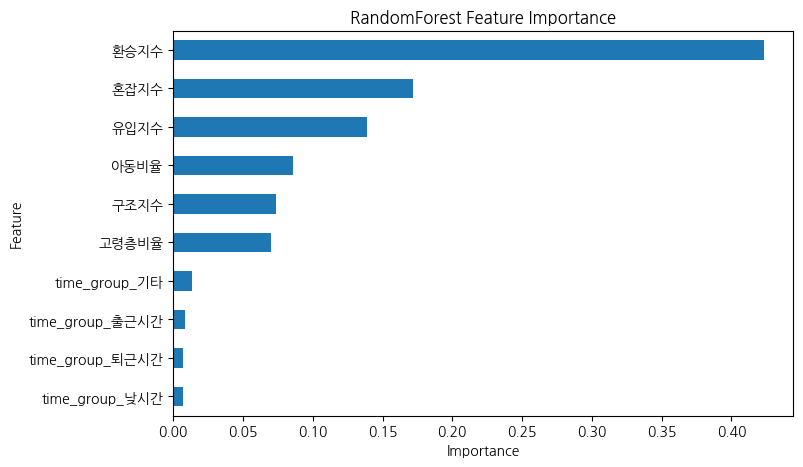

In [ ]:
# 변수 중요도 시각화
# XGBoost 모델이 사고발생 예측에 어떤 변수를 중요하게 사용했는지 그래프로 확인

# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum

# matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 변수 중요도 막대그래프
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('RandomForest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Risk Score 붙이기

In [ ]:
# Risk Score 생성
# RandomForest 모델의 사고발생 예측확률을 0~100점 위험도 점수로 변환

# Risk: 사고발생 예측확률, 0~1 사이 값
df_model['Risk'] = rf.predict_proba(X)[:, 1]

# Risk_Score: 해석하기 쉽도록 100점 만점으로 변환
df_model['Risk_Score'] = df_model['Risk'] * 100

# Risk Score 확인
df_model[['역명_clean', '호선명', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,0.401839,40.183936,0,0
1,동대문,1호선,0.531647,53.164679,0,0
2,동대문,1호선,0.581157,58.115739,0,0
3,동대문,1호선,0.502840,50.284005,0,0
4,동묘앞,1호선,0.197719,19.771943,0,0


In [ ]:
# 원본 df에도 Risk Score 붙이기
# df에는 time_group 컬럼이 남아 있으므로 역·호선·시간대별 위험도 확인 가능

df['Risk'] = df_model['Risk']
df['Risk_Score'] = df_model['Risk_Score']

# 역·호선·시간대별 Risk Score 확인
df[['역명_clean', '호선명', 'time_group', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,time_group,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,기타,0.401839,40.183936,0,0
1,동대문,1호선,낮시간,0.531647,53.164679,0,0
2,동대문,1호선,출근시간,0.581157,58.115739,0,0
3,동대문,1호선,퇴근시간,0.502840,50.284005,0,0
4,동묘앞,1호선,기타,0.197719,19.771943,0,0


In [ ]:
# 역·호선·시간대별 위험도 순위 생성
# 같은 역/호선/시간대 조합이 여러 행에 존재할 수 있으므로 평균 Risk Score로 집계
# 사고수는 실제 사고 발생 규모 확인을 위해 합계로 집계

top_risk_station_time = (
    df
    .groupby(['역명_clean', '호선명', 'time_group'], as_index=False)
    .agg(
        Risk_Score=('Risk_Score', 'mean'),
        Risk=('Risk', 'mean'),
        사고수=('사고수', 'sum'),
        사고발생=('사고발생', 'max'),
        혼잡지수=('혼잡지수', 'mean'),
        유입지수=('유입지수', 'mean'),
        구조지수=('구조지수', 'mean'),
        환승지수=('환승지수', 'mean')
    )
    .sort_values('Risk_Score', ascending=False)
)

# 위험도 상위 20개 역·호선·시간대 확인
top_risk_station_time.head(20)

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수
519,사당,2호선,퇴근시간,87.672797,0.876728,11,1,2.543994e-01,0.238396,0.357143,0.597375
841,연신내,3호선,낮시간,86.695006,0.866950,12,1,2.281283e-01,0.124169,0.607143,0.127354
517,사당,2호선,낮시간,85.131452,0.851315,12,1,2.463075e-01,0.225071,0.357143,0.597375
321,동대문,4호선,낮시간,84.860694,0.848607,11,1,1.779956e-01,0.237162,0.750000,0.219240
523,사당,4호선,퇴근시간,84.041713,0.840417,10,1,1.373551e-01,0.377957,0.267857,0.597375
703,신도림,2호선,퇴근시간,83.837584,0.838376,17,1,2.792300e-01,0.256430,0.267857,1.000000
921,을지로3가,2호선,낮시간,83.565029,0.835650,7,1,1.306260e-01,0.365907,0.392857,0.266542
1157,합정,2호선,낮시간,82.460611,0.824606,5,1,2.121925e-01,0.351333,0.392857,0.343655
81,고속터미널,3호선,낮시간,82.386481,0.823865,8,1,4.024523e-01,0.253992,0.464286,0.699515
85,고속터미널,7호선,낮시간,82.385729,0.823857,13,1,1.237434e-01,0.225579,0.678571,0.699515


In [ ]:
# 위험 유형 분류
# 각 역·호선·시간대 조합에서 가장 높은 지수를 기준으로 위험 유형을 부여
# 예: 혼잡지수가 가장 높으면 혼잡형, 구조지수가 가장 높으면 구조형

def classify_risk_type(row):
    values = {
        '혼잡형': row['혼잡지수'],
        '유입형': row['유입지수'],
        '구조형': row['구조지수'],
        '환승형': row['환승지수']
    }
    return max(values, key=values.get)

top_risk_station_time['위험유형'] = top_risk_station_time.apply(classify_risk_type, axis=1)

# 위험도 상위 20개 역·호선·시간대와 위험유형 확인
top_risk_station_time.head(20)

# 시간 기준 모델의 위험도 상위 역·시간대 결과 해석
# Risk Score 상위 20개 구간은 모두 사고발생=1로 나타남
# 즉, 모델이 위험도가 높다고 판단한 역·호선·시간대가 실제 사고 발생 구간과 잘 대응됨

# 상위 위험 구간 예시
# 사당 2호선 퇴근시간: Risk Score 87.67, 사고수 11건
# 연신내 3호선 낮시간: Risk Score 86.70, 사고수 12건
# 사당 2호선 낮시간: Risk Score 85.13, 사고수 12건
# 동대문 4호선 낮시간: Risk Score 84.86, 사고수 11건
# 사당 4호선 퇴근시간: Risk Score 84.04, 사고수 10건
# 신도림 2호선 퇴근시간: Risk Score 83.84, 사고수 17건

# 위험유형 해석
# 상위 위험 구간은 환승형과 구조형이 다수로 나타남
# 사당, 신도림, 고속터미널 등은 환승지수가 높아 환승형으로 분류됨
# 연신내, 동대문, 을지로3가 등은 구조지수가 높아 구조형으로 분류됨

# 결론
# 시간 기준으로 학습·평가한 RandomForest 기반 Risk Score는
# 실제 사고가 발생한 역·시간대를 상위 위험구간으로 효과적으로 선별함
# 따라서 본 모델은 역별·시간대별 안전관리 우선순위 선정과
# 위험유형별 맞춤형 대응 전략 수립에 활용할 수 있음

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수,위험유형
519,사당,2호선,퇴근시간,87.672797,0.876728,11,1,2.543994e-01,0.238396,0.357143,0.597375,환승형
841,연신내,3호선,낮시간,86.695006,0.866950,12,1,2.281283e-01,0.124169,0.607143,0.127354,구조형
517,사당,2호선,낮시간,85.131452,0.851315,12,1,2.463075e-01,0.225071,0.357143,0.597375,환승형
321,동대문,4호선,낮시간,84.860694,0.848607,11,1,1.779956e-01,0.237162,0.750000,0.219240,구조형
523,사당,4호선,퇴근시간,84.041713,0.840417,10,1,1.373551e-01,0.377957,0.267857,0.597375,환승형
703,신도림,2호선,퇴근시간,83.837584,0.838376,17,1,2.792300e-01,0.256430,0.267857,1.000000,환승형
921,을지로3가,2호선,낮시간,83.565029,0.835650,7,1,1.306260e-01,0.365907,0.392857,0.266542,구조형
1157,합정,2호선,낮시간,82.460611,0.824606,5,1,2.121925e-01,0.351333,0.392857,0.343655,구조형
81,고속터미널,3호선,낮시간,82.386481,0.823865,8,1,4.024523e-01,0.253992,0.464286,0.699515,환승형
85,고속터미널,7호선,낮시간,82.385729,0.823857,13,1,1.237434e-01,0.225579,0.678571,0.699515,환승형
